In [1]:
import os
import mne
import scipy
import numpy as np
import matplotlib.pyplot as plt

from utils.utils import combine_labels, crop_brain_and_make_transparent, mm_to_inches
from utils.configs import (
    NUM_VERTEX_DICT,
    ATLAS,
    MidTL_LH, MidTL_RH,
    ATL_LH, ATL_RH
)

plt.rcParams["font.family"] = "Arial"

# Parameters
SUBJECTS_DIR = "./freesurfer"
SUBJECT = "fsaverage"
RESULTS_ROOT = "./results"
ALPHA = 0.001
SPACING = "ico4"
NUM_VERTEX = NUM_VERTEX_DICT[SPACING]
P_THRESH = 0.05

In [2]:
midTL_label_lh = combine_labels(SUBJECT, SUBJECTS_DIR, ATLAS, MidTL_LH)
midTL_label_rh = combine_labels(SUBJECT, SUBJECTS_DIR, ATLAS, MidTL_RH)
midTL_label_lh.name = "MidTL-lh"
midTL_label_rh.name = "MidTL-rh"

ATL_label_lh = combine_labels(SUBJECT, SUBJECTS_DIR, ATLAS, ATL_LH)
ATL_label_rh = combine_labels(SUBJECT, SUBJECTS_DIR, ATLAS, ATL_RH)
ATL_label_lh.name = "ATL-lh"
ATL_label_rh.name = "ATL-rh"

src = mne.read_source_spaces(os.path.join(
    SUBJECTS_DIR, SUBJECT,
    "bem", f"{SUBJECT}-{SPACING}-src.fif"
))

print(midTL_label_lh.name, len(midTL_label_lh), midTL_label_lh.compute_area(SUBJECT, SUBJECTS_DIR) * 1e4)
print(midTL_label_rh.name, len(midTL_label_rh), midTL_label_rh.compute_area(SUBJECT, SUBJECTS_DIR) * 1e4)
print(ATL_label_lh.name, len(ATL_label_lh), ATL_label_lh.compute_area(SUBJECT, SUBJECTS_DIR) * 1e4)
print(ATL_label_rh.name, len(ATL_label_rh), ATL_label_rh.compute_area(SUBJECT, SUBJECTS_DIR) * 1e4)

Reading labels from parcellation...
   read 201 labels from f:\YWJ-Lab-Proj\ConjSemProj\freesurfer\fsaverage\label\lh.Schaefer2018_400Parcels_17Networks_order.annot
   read 201 labels from f:\YWJ-Lab-Proj\ConjSemProj\freesurfer\fsaverage\label\rh.Schaefer2018_400Parcels_17Networks_order.annot
Reading labels from parcellation...
   read 201 labels from f:\YWJ-Lab-Proj\ConjSemProj\freesurfer\fsaverage\label\lh.Schaefer2018_400Parcels_17Networks_order.annot
   read 201 labels from f:\YWJ-Lab-Proj\ConjSemProj\freesurfer\fsaverage\label\rh.Schaefer2018_400Parcels_17Networks_order.annot
Reading labels from parcellation...
   read 201 labels from f:\YWJ-Lab-Proj\ConjSemProj\freesurfer\fsaverage\label\lh.Schaefer2018_400Parcels_17Networks_order.annot
   read 201 labels from f:\YWJ-Lab-Proj\ConjSemProj\freesurfer\fsaverage\label\rh.Schaefer2018_400Parcels_17Networks_order.annot
Reading labels from parcellation...
   read 201 labels from f:\YWJ-Lab-Proj\ConjSemProj\freesurfer\fsaverage\label\lh.

### Results: Conjuntions

Using pyvistaqt 3d backend.



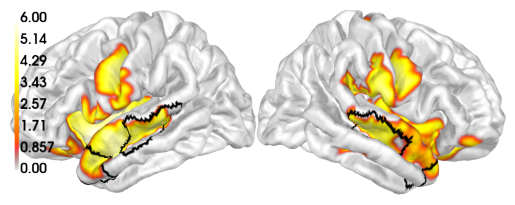

In [3]:
results_dir = os.path.join(RESULTS_ROOT, "6.1-Source_Activation_Conj")
npy_dir = os.path.join(results_dir, "npy")
stc_dir = os.path.join(results_dir, "stc")
img_dir = os.path.join(results_dir, "img")

os.makedirs(img_dir, exist_ok=True)

duration_stc = mne.read_source_estimate(os.path.join(stc_dir, f"T-obs-good_alpha-{ALPHA}"))

merged_labels = [midTL_label_lh, midTL_label_rh,
                 ATL_label_lh, ATL_label_rh]

brain = duration_stc.plot(
    hemi="split",
    subjects_dir=SUBJECTS_DIR,
    subject=SUBJECT,
    colormap="hot",
    colorbar=True,
    views="lateral",
    size=(800, 400),
    initial_time=0,
    smoothing_steps=15,
    background="white",
    transparent=True,
    cortex=[0.9, 0.9, 0.9],
    surface="pial",
    clim=dict(kind="value", lims=[0, 1.2, 6]),
    show_traces=True
)

for label in merged_labels:
    brain.add_label(label, borders=True, color="black")
for hemi in brain.geo:
    geo = brain.geo[hemi]
    if hasattr(geo, "_borders"):
        for actor in geo._borders:
            actor.GetProperty().SetLineWidth(10)

image = brain.screenshot()
fig_brain = crop_brain_and_make_transparent(image)
fig_brain.savefig(os.path.join(img_dir, f"brainplot.svg"),
                  transparent=True, dpi=600, format="svg", bbox_inches="tight")

plt.show()


############## MidTL-lh ##############
Using a threshold of 2.034515
stat_fun(H1): min=-0.777348 max=6.440636
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 2.380s-2.605s

############## MidTL-rh ##############
Using a threshold of 2.034515
stat_fun(H1): min=-3.133356 max=5.328090
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 2.365s-2.780s

############## ATL-lh ##############
Using a threshold of 2.034515
stat_fun(H1): min=-5.794108 max=5.551159
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 2.670s-2.870s
Suggested significant times: 2.350s-2.585s

############## ATL-rh ##############
Using a threshold of 2.034515
stat_fun(H1): min=-6.004718 max=6.485140
Running initial clustering …
Found 6 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 2.700s-2.870s
Suggested significant times: 2.365s-2.580s


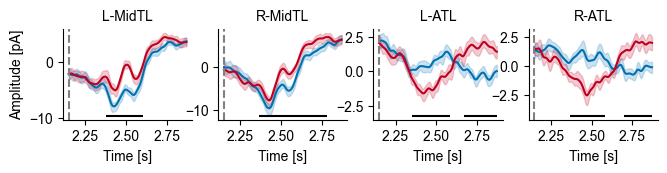

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(mm_to_inches(195, 30)))
titles = ["L-MidTL", "R-MidTL", "L-ATL", "R-ATL"]

stc_data = np.load(os.path.join(npy_dir, "subject_evoked.npy"))
time_vector = np.load(os.path.join(npy_dir, "time_vector.npy"))

sta_data = stc_data[:, 0, :, :]
dev_data = stc_data[:, 1, :, :]

onset = 2.15

for idx, (label, ax, title) in enumerate(zip(merged_labels, axes, titles)):
    print("\n" + "#" * 14 + " " + label.name + " " + "#" * 14)
    if label.hemi == "lh":
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2))
    else:
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2)) + NUM_VERTEX//2
    
    flip = mne.label_sign_flip(label, src)

    dev_timeseries = (dev_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12
    sta_timeseries = (sta_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12

    X = dev_timeseries - sta_timeseries
    T_obs, clusters, p_values, _ = mne.stats.permutation_cluster_1samp_test(
        X, n_permutations=1000, tail=0, n_jobs=4, seed=1016
    )

    sta_mean = sta_timeseries.mean(axis=0)
    sta_se = sta_timeseries.std(axis=0) / np.sqrt(sta_timeseries.shape[0])

    dev_mean = dev_timeseries.mean(axis=0)
    dev_se = dev_timeseries.std(axis=0) / np.sqrt(dev_timeseries.shape[0])

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(sta_mean, sigma=2), color="#0072b2", linewidth=1.5, label="STA")
    ax.fill_between(time_vector, sta_mean - sta_se, sta_mean + sta_se, color="#0072b2", alpha=0.2)

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(dev_mean, sigma=2), color="#C10020", linewidth=1.5, label="DEV")
    ax.fill_between(time_vector, dev_mean - dev_se, dev_mean + dev_se, color="#C10020", alpha=0.2)

    ax.set_title(title, fontsize=10)

    sig_y = min(sta_mean.min(), dev_mean.min()) - 1.5
    for clu_idx, clu in enumerate(clusters):
        if p_values[clu_idx] < P_THRESH:
            t_inds = clu[0]
            start_time = time_vector[t_inds[0]]
            end_time = time_vector[t_inds[-1]]
            if end_time - start_time < 0.1:
                continue
            print(f"Suggested significant times: {start_time:.3f}s-{end_time:.3f}s")
            ax.hlines(y=sig_y, xmin=start_time, xmax=end_time, colors="black", linewidth=1.5, alpha=1)
    
    ax.set_xlabel("Time [s]", fontsize=10)
    if idx == 0:
        ax.set_ylabel("Amplitude [pA]", fontsize=10)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axvline(onset, linestyle="--", color="gray")

plt.show()    

### Results: Semantics

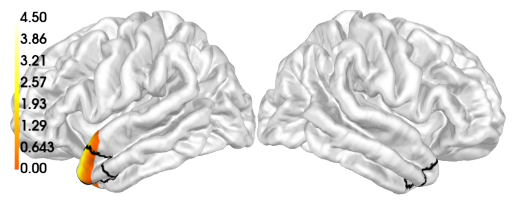

In [ ]:
results_dir = os.path.join(RESULTS_ROOT, "6.2-Source_Activation_Sem")
npy_dir = os.path.join(results_dir, "npy")
stc_dir = os.path.join(results_dir, "stc")
img_dir = os.path.join(results_dir, "img")

os.makedirs(img_dir, exist_ok=True)

duration_stc = mne.read_source_estimate(os.path.join(stc_dir, f"T-obs-good_alpha-{ALPHA}"))

merged_labels = [ATL_label_lh, ATL_label_rh]

brain = duration_stc.plot(
    hemi="split",
    subjects_dir=SUBJECTS_DIR,
    subject=SUBJECT,
    colormap="hot",
    colorbar=True,
    views="lateral",
    size=(800, 400),
    initial_time=0,
    smoothing_steps=15,
    background="white",
    transparent=True,
    cortex=[0.9, 0.9, 0.9],
    surface="pial",
    clim=dict(kind="value", lims=[0, 0, 4.5])
)

for label in merged_labels:
    brain.add_label(label, borders=True, color="black")
for hemi in brain.geo:
    geo = brain.geo[hemi]
    if hasattr(geo, "_borders"):
        for actor in geo._borders:
            actor.GetProperty().SetLineWidth(10)

image = brain.screenshot()
fig_brain = crop_brain_and_make_transparent(image)
fig_brain.savefig(os.path.join(img_dir, f"brainplot.svg"),
                  transparent=True, dpi=600, format="svg", bbox_inches="tight")

plt.show()

##############MidTL-lh##############
Using a threshold of 2.034515
stat_fun(H1): min=-2.568679 max=3.838368
Running initial clustering …
Found 9 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

##############MidTL-rh##############
Using a threshold of 2.034515
stat_fun(H1): min=-2.139153 max=2.525769
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

##############ATL-lh##############
Using a threshold of 2.034515
stat_fun(H1): min=-4.511151 max=2.668958
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 3.860s-4.070s
##############ATL-rh##############
Using a threshold of 2.034515
stat_fun(H1): min=-2.597041 max=2.549937
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

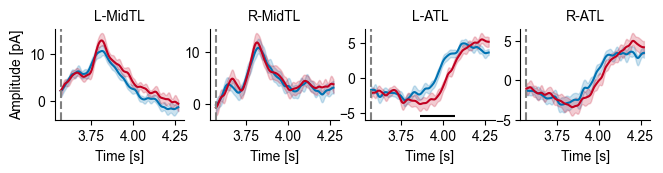

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(mm_to_inches(195, 30)))
titles = ["L-MidTL", "R-MidTL", "L-ATL", "R-ATL"]

merged_labels = [midTL_label_lh, midTL_label_rh,
                 ATL_label_lh, ATL_label_rh]

stc_data = np.load(os.path.join(npy_dir, "subject_evoked.npy"))
time_vector = np.load(os.path.join(npy_dir, "time_vector.npy"))

sta_data = stc_data[:, 0, :, :]
dev_data = stc_data[:, 1, :, :]

onset = 3.57

for idx, (label, ax, title) in enumerate(zip(merged_labels, axes, titles)):
    print("#" * 14 + label.name + "#" * 14)
    if label.hemi == "lh":
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2))
    else:
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2)) + NUM_VERTEX//2
    
    flip = mne.label_sign_flip(label, src)

    dev_timeseries = (dev_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12
    sta_timeseries = (sta_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12

    X = dev_timeseries - sta_timeseries
    T_obs, clusters, p_values, _ = mne.stats.permutation_cluster_1samp_test(
        X, n_permutations=1000, tail=0, n_jobs=4, seed=1016
    )

    sta_mean = sta_timeseries.mean(axis=0)
    sta_se = sta_timeseries.std(axis=0) / np.sqrt(sta_timeseries.shape[0])

    dev_mean = dev_timeseries.mean(axis=0)
    dev_se = dev_timeseries.std(axis=0) / np.sqrt(dev_timeseries.shape[0])

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(sta_mean, sigma=2), color="#0072b2", linewidth=1.5, label="STA")
    ax.fill_between(time_vector, sta_mean - sta_se, sta_mean + sta_se, color="#0072b2", alpha=0.2)

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(dev_mean, sigma=2), color="#C10020", linewidth=1.5, label="DEV")
    ax.fill_between(time_vector, dev_mean - dev_se, dev_mean + dev_se, color="#C10020", alpha=0.2)

    ax.set_title(title, fontsize=10)

    sig_y = min(sta_mean.min(), dev_mean.min()) - 1.5
    for clu_idx, clu in enumerate(clusters):
        if p_values[clu_idx] < P_THRESH:
            t_inds = clu[0]
            start_time = time_vector[t_inds[0]]
            end_time = time_vector[t_inds[-1]]
            if end_time - start_time < 0.1:
                continue
            print(f"Suggested significant times: {start_time:.3f}s-{end_time:.3f}s")
            ax.hlines(y=sig_y, xmin=start_time, xmax=end_time, colors="black", linewidth=1.5, alpha=1)
    
    ax.set_xlabel("Time [s]", fontsize=10)
    if idx == 0:
        ax.set_ylabel("Amplitude [pA]", fontsize=10)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axvline(onset, linestyle="--", color="gray")

plt.show()    

### Results (Cross-Block): 
#### 1) Block-1 标准句 v.s. Block-2 异常句

##############MidTL-lh##############
Using a threshold of 2.032245
stat_fun(H1): min=-3.263397 max=3.858865
Running initial clustering …
Found 9 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

##############ATL-lh##############
Using a threshold of 2.032245
stat_fun(H1): min=-5.655503 max=1.290340
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 3.930s-4.270s


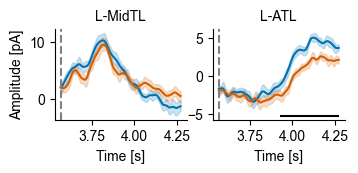

In [4]:
results_dir = os.path.join(RESULTS_ROOT, "6.3-Source_Activation_CrossBlock-1")

fig, axes = plt.subplots(1, 2, figsize=(mm_to_inches(95, 30)))
titles = ["L-MidTL", "L-ATL"]

merged_labels = [midTL_label_lh, ATL_label_lh]

stc_data = np.load(os.path.join(results_dir, "subject_evoked.npy"))
time_vector = np.load(os.path.join(results_dir, "time_vector.npy"))

b1_data = stc_data[:, 0, :, :]
b2_data = stc_data[:, 1, :, :]

onset = 3.57

for idx, (label, ax, title) in enumerate(zip(merged_labels, axes, titles)):
    print("#" * 14 + label.name + "#" * 14)
    if label.hemi == "lh":
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2))
    else:
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2)) + NUM_VERTEX//2
    
    flip = mne.label_sign_flip(label, src)

    b1_timeseries = (b1_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12
    b2_timeseries = (b2_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12

    X = b2_timeseries - b1_timeseries
    T_obs, clusters, p_values, _ = mne.stats.permutation_cluster_1samp_test(
        X, n_permutations=1000, tail=0, n_jobs=4, seed=1016
    )

    b1_mean = b1_timeseries.mean(axis=0)
    b1_se = b1_timeseries.std(axis=0) / np.sqrt(b1_timeseries.shape[0])

    b2_mean = b2_timeseries.mean(axis=0)
    b2_se = b2_timeseries.std(axis=0) / np.sqrt(b2_timeseries.shape[0])

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(b1_mean, sigma=2), color="#0072b2", linewidth=1.5, label="STA")
    ax.fill_between(time_vector, b1_mean - b1_se, b1_mean + b1_se, color="#0072b2", alpha=0.2)

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(b2_mean, sigma=2), color="#d55e00", linewidth=1.5, label="DEVSYN_C2")
    ax.fill_between(time_vector, b2_mean - b2_se, b2_mean + b2_se, color="#d55e00", alpha=0.2)

    ax.set_title(title, fontsize=10)

    sig_y = min(b1_mean.min(), b2_mean.min()) - 1.5
    for clu_idx, clu in enumerate(clusters):
        if p_values[clu_idx] < P_THRESH:
            t_inds = clu[0]
            start_time = time_vector[t_inds[0]]
            end_time = time_vector[t_inds[-1]]
            if end_time - start_time < 0.1:
                continue
            print(f"Suggested significant times: {start_time:.3f}s-{end_time:.3f}s")
            ax.hlines(y=sig_y, xmin=start_time, xmax=end_time, colors="black", linewidth=1.5, alpha=1)
    
    ax.set_xlabel("Time [s]", fontsize=10)
    if idx == 0:
        ax.set_ylabel("Amplitude [pA]", fontsize=10)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axvline(onset, linestyle="--", color="gray")

plt.show()    

#### 2) Block-1 标准句 v.s. Block-3 异常句

##############MidTL-lh##############
Using a threshold of 2.032245
stat_fun(H1): min=-4.486175 max=5.512171
Running initial clustering …
Found 4 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 4.030s-4.270s
##############ATL-lh##############
Using a threshold of 2.032245
stat_fun(H1): min=-7.178274 max=3.358570
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 3.885s-4.240s


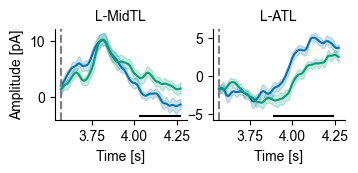

In [5]:
results_dir = os.path.join(RESULTS_ROOT, "6.3-Source_Activation_CrossBlock-1")

fig, axes = plt.subplots(1, 2, figsize=(mm_to_inches(95, 30)))
titles = ["L-MidTL", "L-ATL"]

merged_labels = [midTL_label_lh, ATL_label_lh]

stc_data = np.load(os.path.join(results_dir, "subject_evoked.npy"))
time_vector = np.load(os.path.join(results_dir, "time_vector.npy"))

b1_data = stc_data[:, 0, :, :]
b3_data = stc_data[:, 2, :, :]

onset = 3.57

for idx, (label, ax, title) in enumerate(zip(merged_labels, axes, titles)):
    print("#" * 14 + label.name + "#" * 14)
    if label.hemi == "lh":
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2))
    else:
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2)) + NUM_VERTEX//2
    
    flip = mne.label_sign_flip(label, src)

    b1_timeseries = (b1_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12
    b3_timeseries = (b3_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12

    X = b3_timeseries - b1_timeseries
    T_obs, clusters, p_values, _ = mne.stats.permutation_cluster_1samp_test(
        X, n_permutations=1000, tail=0, n_jobs=4, seed=1016
    )

    b1_mean = b1_timeseries.mean(axis=0)
    b1_se = b1_timeseries.std(axis=0) / np.sqrt(b1_timeseries.shape[0])

    b3_mean = b3_timeseries.mean(axis=0)
    b3_se = b3_timeseries.std(axis=0) / np.sqrt(b3_timeseries.shape[0])

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(b1_mean, sigma=2), color="#0072b2", linewidth=1.5, label="STA")
    ax.fill_between(time_vector, b1_mean - b1_se, b1_mean + b1_se, color="#0072b2", alpha=0.2)

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(b3_mean, sigma=2), color="#009e73", linewidth=1.5, label="DEVSYN_C1")
    ax.fill_between(time_vector, b3_mean - b3_se, b3_mean + b3_se, color="#009e73", alpha=0.2)

    ax.set_title(title, fontsize=10)

    sig_y = min(b1_mean.min(), b3_mean.min()) - 1.5
    for clu_idx, clu in enumerate(clusters):
        if p_values[clu_idx] < P_THRESH:
            t_inds = clu[0]
            start_time = time_vector[t_inds[0]]
            end_time = time_vector[t_inds[-1]]
            if end_time - start_time < 0.1:
                continue
            print(f"Suggested significant times: {start_time:.3f}s-{end_time:.3f}s")
            ax.hlines(y=sig_y, xmin=start_time, xmax=end_time, colors="black", linewidth=1.5, alpha=1)
    
    ax.set_xlabel("Time [s]", fontsize=10)
    if idx == 0:
        ax.set_ylabel("Amplitude [pA]", fontsize=10)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axvline(onset, linestyle="--", color="gray")

plt.show()

#### 3) Block-2 异常句 v.s. Block-3 异常句 (句尾)

##############MidTL-lh##############
Using a threshold of 2.032245
stat_fun(H1): min=-1.329239 max=3.472509
Running initial clustering …
Found 4 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Suggested significant times: 3.905s-4.020s
##############ATL-lh##############
Using a threshold of 2.032245
stat_fun(H1): min=-2.196370 max=3.949164
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

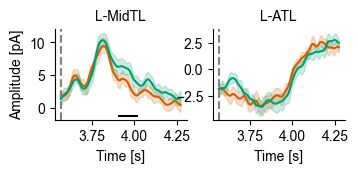

In [6]:
results_dir = os.path.join(RESULTS_ROOT, "6.3-Source_Activation_CrossBlock-1")

fig, axes = plt.subplots(1, 2, figsize=(mm_to_inches(95, 30)))
titles = ["L-MidTL", "L-ATL"]

merged_labels = [midTL_label_lh, ATL_label_lh]

stc_data = np.load(os.path.join(results_dir, "subject_evoked.npy"))
time_vector = np.load(os.path.join(results_dir, "time_vector.npy"))

b2_data = stc_data[:, 1, :, :]
b3_data = stc_data[:, 2, :, :]

onset = 3.57

for idx, (label, ax, title) in enumerate(zip(merged_labels, axes, titles)):
    print("#" * 14 + label.name + "#" * 14)
    if label.hemi == "lh":
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2))
    else:
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2)) + NUM_VERTEX//2
    
    flip = mne.label_sign_flip(label, src)

    b2_timeseries = (b2_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12
    b3_timeseries = (b3_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12

    X = b3_timeseries - b2_timeseries
    T_obs, clusters, p_values, _ = mne.stats.permutation_cluster_1samp_test(
        X, n_permutations=1000, tail=0, n_jobs=4, seed=1016
    )

    b2_mean = b2_timeseries.mean(axis=0)
    b2_se = b2_timeseries.std(axis=0) / np.sqrt(b2_timeseries.shape[0])

    b3_mean = b3_timeseries.mean(axis=0)
    b3_se = b3_timeseries.std(axis=0) / np.sqrt(b3_timeseries.shape[0])

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(b2_mean, sigma=2), color="#d55e00", linewidth=1.5, label="DEVSYN_C2")
    ax.fill_between(time_vector, b2_mean - b2_se, b2_mean + b2_se, color="#d55e00", alpha=0.2)

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(b3_mean, sigma=2), color="#009e73", linewidth=1.5, label="DEVSYN_C1")
    ax.fill_between(time_vector, b3_mean - b3_se, b3_mean + b3_se, color="#009e73", alpha=0.2)

    ax.set_title(title, fontsize=10)

    sig_y = min(b2_mean.min(), b3_mean.min()) - 1.5
    for clu_idx, clu in enumerate(clusters):
        if p_values[clu_idx] < P_THRESH:
            t_inds = clu[0]
            start_time = time_vector[t_inds[0]]
            end_time = time_vector[t_inds[-1]]
            if end_time - start_time < 0.1:
               continue
            print(f"Suggested significant times: {start_time:.3f}s-{end_time:.3f}s")
            ax.hlines(y=sig_y, xmin=start_time, xmax=end_time, colors="black", linewidth=1.5, alpha=1)
    
    ax.set_xlabel("Time [s]", fontsize=10)
    if idx == 0:
        ax.set_ylabel("Amplitude [pA]", fontsize=10)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axvline(onset, linestyle="--", color="gray")

plt.show() 

#### 4) Block-2 异常句 v.s. Block-3 异常句 (句中)

##############MidTL-lh##############
Using a threshold of 2.034515
stat_fun(H1): min=-1.179758 max=2.759347
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

##############ATL-lh##############
Using a threshold of 2.034515
stat_fun(H1): min=-2.111163 max=2.172915
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

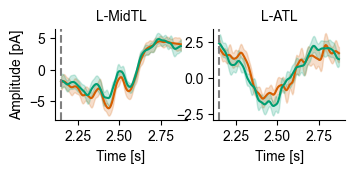

In [8]:
results_dir = os.path.join(RESULTS_ROOT, "6.3-Source_Activation_CrossBlock-2")

fig, axes = plt.subplots(1, 2, figsize=(mm_to_inches(95, 30)))
titles = ["L-MidTL", "L-ATL"]

merged_labels = [midTL_label_lh, ATL_label_lh]

stc_data = np.load(os.path.join(results_dir, "subject_evoked.npy"))
time_vector = np.load(os.path.join(results_dir, "time_vector.npy"))

b2_data = stc_data[:, 0, :, :]
b3_data = stc_data[:, 1, :, :]

onset = 2.150

for idx, (label, ax, title) in enumerate(zip(merged_labels, axes, titles)):
    print("#" * 14 + label.name + "#" * 14)
    if label.hemi == "lh":
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2))
    else:
        vertices_inds = label.get_vertices_used(np.arange(0, NUM_VERTEX//2)) + NUM_VERTEX//2
    
    flip = mne.label_sign_flip(label, src)

    b2_timeseries = (b2_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12
    b3_timeseries = (b3_data[:, vertices_inds, :] * flip[np.newaxis, :, np.newaxis]).mean(axis=1) * 1e12

    X = b3_timeseries - b2_timeseries
    T_obs, clusters, p_values, _ = mne.stats.permutation_cluster_1samp_test(
        X, n_permutations=1000, tail=0, n_jobs=4, seed=1016
    )

    b2_mean = b2_timeseries.mean(axis=0)
    b2_se = b2_timeseries.std(axis=0) / np.sqrt(b2_timeseries.shape[0])

    b3_mean = b3_timeseries.mean(axis=0)
    b3_se = b3_timeseries.std(axis=0) / np.sqrt(b3_timeseries.shape[0])

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(b2_mean, sigma=2), color="#d55e00", linewidth=1.5, label="STA")
    ax.fill_between(time_vector, b2_mean - b2_se, b2_mean + b2_se, color="#d55e00", alpha=0.2)

    ax.plot(time_vector, scipy.ndimage.gaussian_filter1d(b3_mean, sigma=2), color="#009e73", linewidth=1.5, label="B2DEV")
    ax.fill_between(time_vector, b3_mean - b3_se, b3_mean + b3_se, color="#009e73", alpha=0.2)

    ax.set_title(title, fontsize=10)

    sig_y = min(b2_mean.min(), b3_mean.min()) - 1.5
    for clu_idx, clu in enumerate(clusters):
        if p_values[clu_idx] < P_THRESH:
            t_inds = clu[0]
            start_time = time_vector[t_inds[0]]
            end_time = time_vector[t_inds[-1]]
            if end_time - start_time < 0.1:
               continue
            print(f"Suggested significant times: {start_time:.3f}s-{end_time:.3f}s")
            ax.hlines(y=sig_y, xmin=start_time, xmax=end_time, colors="black", linewidth=1.5, alpha=1)
    
    ax.set_xlabel("Time [s]", fontsize=10)
    if idx == 0:
        ax.set_ylabel("Amplitude [pA]", fontsize=10)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axvline(onset, linestyle="--", color="gray")

plt.show()    